# Trees

A **tree** is a connected graph with no cycles. Trees are one of the most useful structures in computer science: file systems, decision trees, parse trees, search trees, and the structure of HTML/JSON documents are all trees.

In this notebook we cover tree terminology, traversals, binary search trees, **Huffman coding**, and **minimum spanning trees**. We will use `networkx` for drawing and Python classes/dictionaries to build trees ourselves.

## Terminology

A **rooted tree** singles out one vertex as the **root** and orients every edge away from it.

- The **root** is the top node (no parent).
- If an edge goes from $u$ down to $v$, then $u$ is the **parent** of $v$ and $v$ is a **child** of $u$.
- A node with no children is a **leaf**; a node with children is an **internal** node.
- The **depth** of a node is its distance from the root (the root has depth $0$).
- The **height** of the tree is the greatest depth of any node.

**Key property.** *A tree with $n$ vertices has exactly $n - 1$ edges.* Intuitively, every vertex except the root is reached by exactly one edge from its parent.

vertices = 8, edges = 7  ->  edges == vertices - 1 ? True


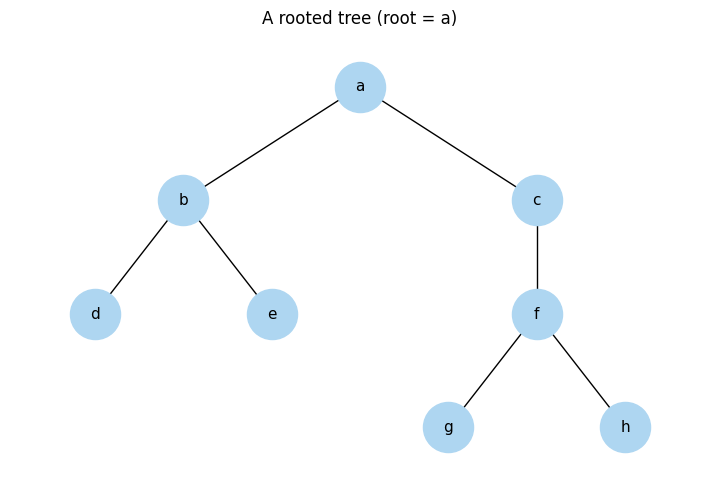

In [1]:
import networkx as nx
import matplotlib.pyplot as plt


def hierarchy_pos(children, root, width=1.0, x=0.0, y=0.0, pos=None):
    """Compute (x, y) positions to draw a rooted tree top-down."""
    if pos is None:
        pos = {}
    pos[root] = (x, y)
    kids = children.get(root, [])
    if kids:
        step = width / len(kids)
        left = x - width / 2 + step / 2
        for i, k in enumerate(kids):
            hierarchy_pos(children, k, step, left + i * step, y - 1, pos)
    return pos


def draw_tree(children, root, labels=None, edge_labels=None, title="", color="#aed6f1"):
    G = nx.DiGraph()
    G.add_node(root)
    stack = [root]
    while stack:
        n = stack.pop()
        for c in children.get(n, []):
            G.add_edge(n, c)
            stack.append(c)
    pos = hierarchy_pos(children, root)
    plt.figure(figsize=(7, 4.5))
    nx.draw(G, pos, with_labels=True, labels=labels, node_color=color,
            node_size=1300, font_size=11, arrows=False)
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11)
    plt.title(title)
    plt.margins(0.1)
    plt.show()


# An example rooted tree.
children = {"a": ["b", "c"], "b": ["d", "e"], "c": ["f"], "f": ["g", "h"]}
n_vertices = len({"a", "b", "c", "d", "e", "f", "g", "h"})
n_edges = sum(len(v) for v in children.values())
print(f"vertices = {n_vertices}, edges = {n_edges}  ->  edges == vertices - 1 ? {n_edges == n_vertices - 1}")

draw_tree(children, "a", title="A rooted tree (root = a)")

## Binary Trees and Tree Traversals

A **binary tree** is a rooted tree in which every node has at most two children, a **left** and a **right** child. We often need to visit every node in some order — a **traversal**. The three classic depth-first traversals differ only in *when* the root is visited relative to its subtrees:

- **Pre-order:** root, then left subtree, then right subtree.
- **In-order:** left subtree, then root, then right subtree.
- **Post-order:** left subtree, then right subtree, then root.

In [2]:
class BinaryNode:
    def __init__(self, val, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right


def preorder(node):
    if node is None:
        return []
    return [node.val] + preorder(node.left) + preorder(node.right)


def inorder(node):
    if node is None:
        return []
    return inorder(node.left) + [node.val] + inorder(node.right)


def postorder(node):
    if node is None:
        return []
    return postorder(node.left) + postorder(node.right) + [node.val]


#         1
#        / \\
#       2   3
#      / \\   \\
#     4   5    6
tree = BinaryNode(1,
                  BinaryNode(2, BinaryNode(4), BinaryNode(5)),
                  BinaryNode(3, None, BinaryNode(6)))

print("pre-order :", preorder(tree))
print("in-order  :", inorder(tree))
print("post-order:", postorder(tree))

pre-order : [1, 2, 4, 5, 3, 6]
in-order  : [4, 2, 5, 1, 3, 6]
post-order: [4, 5, 2, 6, 3, 1]


## Binary Search Trees

A **binary search tree (BST)** is a binary tree that keeps its values ordered: for every node, all values in its **left** subtree are smaller, and all values in its **right** subtree are larger. This ordering makes lookup, insertion, and deletion efficient (about $O(\log n)$ for a balanced tree).

A useful fact: an **in-order traversal of a BST visits the values in sorted order.**

In [3]:
def bst_insert(root, val):
    if root is None:
        return BinaryNode(val)
    if val < root.val:
        root.left = bst_insert(root.left, val)
    else:
        root.right = bst_insert(root.right, val)
    return root


root = None
for v in [5, 3, 8, 1, 4, 7, 9, 2]:
    root = bst_insert(root, v)

print("inserted:        ", [5, 3, 8, 1, 4, 7, 9, 2])
print("in-order (sorted):", inorder(root))

inserted:         [5, 3, 8, 1, 4, 7, 9, 2]
in-order (sorted): [1, 2, 3, 4, 5, 7, 8, 9]


## Huffman Coding

**Huffman coding** is a classic application of binary trees to **data compression**. Instead of giving every character the same number of bits, it gives **frequent characters short codes** and rare characters longer codes, producing a *variable-length prefix code* (no code is a prefix of another, so decoding is unambiguous).

The algorithm builds a binary tree from the bottom up: repeatedly take the two lowest-frequency nodes and join them under a new parent, until one tree remains. Going **left = 0** and **right = 1** from the root to a leaf spells out that character's code.

In [4]:
import heapq


class HuffNode:
    def __init__(self, freq, symbol=None, left=None, right=None):
        self.freq = freq
        self.symbol = symbol
        self.left = left
        self.right = right


def build_huffman_tree(frequencies):
    heap = []
    for i, (sym, w) in enumerate(frequencies.items()):
        # include a counter so heap comparisons never reach the HuffNode objects
        heapq.heappush(heap, (w, i, HuffNode(w, sym)))
    counter = len(frequencies)
    while len(heap) > 1:
        w1, _, n1 = heapq.heappop(heap)
        w2, _, n2 = heapq.heappop(heap)
        heapq.heappush(heap, (w1 + w2, counter, HuffNode(w1 + w2, None, n1, n2)))
        counter += 1
    return heap[0][2]


def huffman_codes(node, prefix="", codes=None):
    if codes is None:
        codes = {}
    if node.symbol is not None:          # leaf
        codes[node.symbol] = prefix or "0"
    else:
        huffman_codes(node.left, prefix + "0", codes)
        huffman_codes(node.right, prefix + "1", codes)
    return codes


text = "abracadabra"
frequencies = {ch: text.count(ch) for ch in sorted(set(text))}
print("character frequencies:", frequencies)

root = build_huffman_tree(frequencies)
codes = huffman_codes(root)
print("Huffman codes:", codes)

character frequencies: {'a': 5, 'b': 2, 'c': 1, 'd': 1, 'r': 2}
Huffman codes: {'a': '0', 'c': '100', 'd': '101', 'b': '110', 'r': '111'}


In [5]:
# Encode the text, then decode it, and measure the compression.
encoded = "".join(codes[ch] for ch in text)
decoder = {code: ch for ch, code in codes.items()}

decoded, buffer = "", ""
for bit in encoded:
    buffer += bit
    if buffer in decoder:
        decoded += decoder[buffer]
        buffer = ""

import math
fixed_bits = math.ceil(math.log2(len(frequencies)))   # bits/char with a fixed-length code

print("encoded bitstring:", encoded)
print("decoded matches original?", decoded == text)
print(f"Huffman:        {len(encoded)} bits")
print(f"Fixed-length:   {len(text) * fixed_bits} bits ({fixed_bits} bits x {len(text)} chars)")
print(f"average Huffman code length: {len(encoded) / len(text):.2f} bits/char")

encoded bitstring: 01101110100010101101110
decoded matches original? True
Huffman:        23 bits
Fixed-length:   33 bits (3 bits x 11 chars)
average Huffman code length: 2.09 bits/char


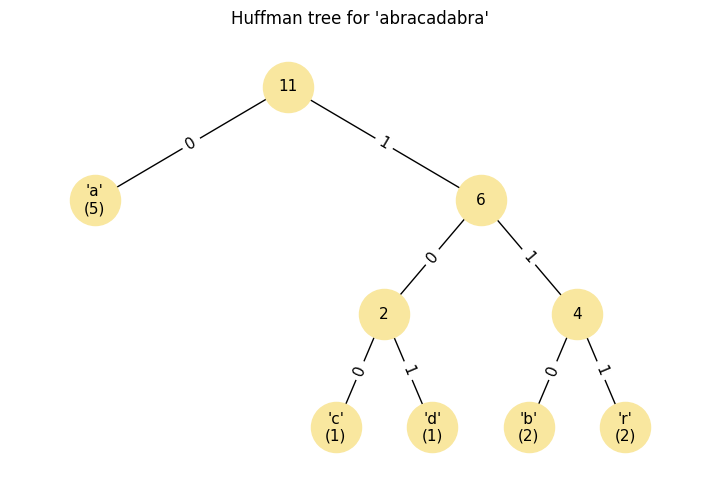

In [6]:
# Draw the Huffman tree: leaves show their symbol, internal nodes show their total frequency.
children, labels, edge_labels = {}, {}, {}
ids = {}
counter = [0]


def walk(node):
    nid = counter[0]
    counter[0] += 1
    ids[node] = nid
    if node.symbol is not None:
        labels[nid] = f"'{node.symbol}'\n({node.freq})"
    else:
        labels[nid] = str(node.freq)
        for bit, child in (("0", node.left), ("1", node.right)):
            cid = walk(child)
            children.setdefault(nid, []).append(cid)
            edge_labels[(nid, cid)] = bit
    return nid


root_id = walk(root)
draw_tree(children, root_id, labels=labels, edge_labels=edge_labels,
          title="Huffman tree for 'abracadabra'", color="#f9e79f")

## Spanning Trees and Minimum Spanning Trees

A **spanning tree** of a connected graph is a subgraph that is a tree and touches **every** vertex — it connects all the vertices using exactly $n - 1$ edges and no cycles.

When the edges have weights (costs, distances), a **minimum spanning tree (MST)** is a spanning tree whose total edge weight is as small as possible. MSTs answer questions like "what is the cheapest way to lay cable so that every building is connected?" Two standard algorithms are **Kruskal's** and **Prim's**; below we let `networkx` compute one for us.

MST edges: [('A', 'B', {'weight': 2}), ('B', 'C', {'weight': 1}), ('B', 'D', {'weight': 4}), ('C', 'E', {'weight': 6})]
Total MST weight: 13


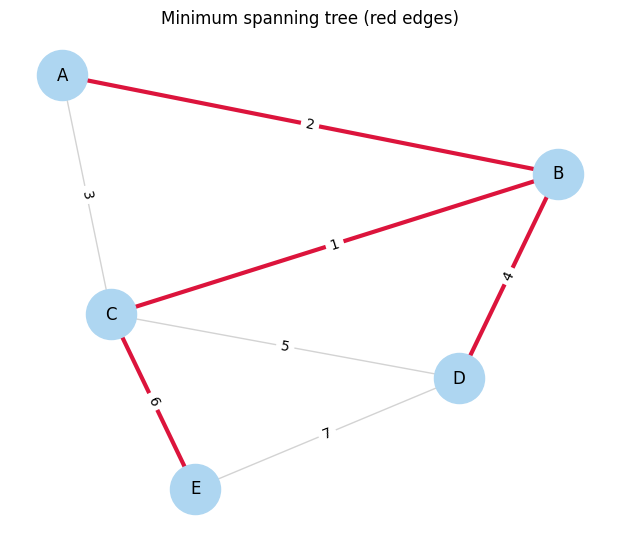

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_weighted_edges_from([
    ("A", "B", 2), ("A", "C", 3), ("B", "C", 1), ("B", "D", 4),
    ("C", "D", 5), ("C", "E", 6), ("D", "E", 7),
])

mst = nx.minimum_spanning_tree(G)            # Kruskal's algorithm by default
mst_edges = set(tuple(sorted(e)) for e in mst.edges())
total_weight = sum(d["weight"] for _, _, d in mst.edges(data=True))
print("MST edges:", sorted(mst.edges(data=True)))
print("Total MST weight:", total_weight)

pos = nx.spring_layout(G, seed=7)
edge_colors = ["crimson" if tuple(sorted(e)) in mst_edges else "lightgray" for e in G.edges()]
edge_widths = [3 if tuple(sorted(e)) in mst_edges else 1 for e in G.edges()]

plt.figure(figsize=(6, 5))
nx.draw(G, pos, with_labels=True, node_color="#aed6f1", node_size=1300,
        edge_color=edge_colors, width=edge_widths, font_size=12)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"))
plt.title("Minimum spanning tree (red edges)")
plt.show()

## Worked Examples

A few examples solved with Python. (The exercises in the next section are for you to solve — their solutions live in the matching notebook in `solutions/`.)

### Example 1: Height of a Binary Tree

The height of a tree is the length of the longest path from the root to a leaf. Compute it recursively (an empty tree has height $-1$, a single node has height $0$).

In [8]:
class Node:
    def __init__(self, val, left=None, right=None):
        self.val, self.left, self.right = val, left, right

def height(n):
    if n is None:
        return -1
    return 1 + max(height(n.left), height(n.right))

t = Node(1, Node(2, Node(4)), Node(3))
print("height:", height(t))

height: 2


### Example 2: Counting the Leaves

A leaf is a node with no children. Count the leaves of the same tree.

In [9]:
def count_leaves(n):
    if n is None:
        return 0
    if n.left is None and n.right is None:
        return 1
    return count_leaves(n.left) + count_leaves(n.right)

print("leaves:", count_leaves(t))

leaves: 2


## Trees Practice Problems

Write your Python in the code cell beneath each problem (some starter code is provided). Worked solutions are in [`solutions/11_trees_key.ipynb`](solutions/11_trees_key.ipynb).

### Problem 1: Edges in a Tree

A tree with $n$ vertices has exactly $n - 1$ edges. Use Python to print the number of edges in a tree with 250 vertices.

In [10]:
n = 250
# WRITE YOUR CODE BELOW


### Problem 2: Tree Traversals

Define a binary-tree node class and functions for pre-order, in-order, and post-order traversal, then print all three for the tree with root `A`, left child `B` (with left child `D`), and right child `C` (with children `E`, `F`).

In [11]:
class Node:
    def __init__(self, val, left=None, right=None):
        self.val, self.left, self.right = val, left, right

# Build the tree and write the three traversals.
# WRITE YOUR CODE BELOW


### Problem 3: Binary Search Tree

Insert the values $6, 2, 8, 1, 4, 3$ into a binary search tree, then show that an in-order traversal returns them in sorted order.

In [12]:
# WRITE YOUR CODE BELOW


### Problem 4: Minimum Spanning Tree

Using `networkx`, find a minimum spanning tree of the weighted graph in the starter and print its total weight.

In [13]:
import networkx as nx
edges = [("A", "B", 2), ("A", "C", 3), ("B", "C", 1), ("B", "D", 4), ("C", "D", 5)]
# WRITE YOUR CODE BELOW
